# Aufgabenblatt 3 - Musterlösung

In [1]:
import numpy as np

# Aufgabe 1 - Mittelwert und Standardabweichung
## **Hintergrund: Python Funktionen**

Funktionen sind ein fundamentales Tool beim Schreiben von Code. Im Folgenden wollen wir eine kleine Einführung zu Funktionen in Python geben. Sie ist gezielt einfach und kurz gehalten, beinhaltet aber alles, was Sie für den Start benötigen.  Die Definition einer Python-Funktion beginnt mit `def`, gefolgt vom Funktionsnamen und, falls benötigt, den zu übergebenden Argumenten in der Klammer. Analog zu for-Schleifen ist der zur Funktion gehörende Code dadurch definiert, dass er eingerückt ist:

```
def function_name(parameter1, parameter2, default_argument=standard_value):
	"""Docstring"""
    # some code
	return return_value1, return_value2
```
    
Dabei können `parameter1`, `parameter2` und `default_argument` beliebige Datentypen sein, z.B. `int`, `np.ndarray`, `str`, etc. Der Unterschied zwischen `default_argument` und `parameter1` oder `parameter2` ist, dass Default Arguments einen Standardwert haben. In der Funktionsdefinition müssen Default Arguments immer **nach** Non-Default Arguments geschrieben werden. Das `return` statement ist nur notwendig, wenn man einen Wert zurückgeben will, und kann ansonsten weggelassen werden. Es können eine oder mehrere mit Kommas separierte Variablen ausgegeben werden, und sie können beliebige Datentypen annehmen.
 
Beim Aufrufen oder Ausführen der Funktion können die Parameter entweder positional oder mit Hilfe von Keywords übergeben werden. Bei der positionalen Übergabe werden die Übergabeparameter in der Reihenfolge, in der die Parameter in der Funktionsdefinition geschrieben sind, übergeben. Bei einem Aufruf `function_name(1,2)` beispielsweise hat also `parameter1` den Wert `1`, `parameter2` den Wert `2` und `default_argument` den Standardwert `standard_value`. Bei der Übergabe mit Keywords kann man die Reihenfolge der Parameter im Aufruf frei wählen, also z. B. `function_name(parameter2='hello!', default_argument=5, parameter1=3.141)`. Man kann die beiden Übergabemethoden auch in einem Aufruf mischen, dann muss man jedoch zuerst alle positionalen Parameter (in der richtigen Reihenfolge) und dann die Keyword Parameter übergeben.

Im Folgenden sind einige einfache Funktionen aufgeführt, die die Funktionsweise illustrieren sollten.


In [2]:
def simple_print():
    print('Always the same.')

def print_input(text):
    print('Prints: {:s}'.format(text))

def linear_function(x, a):
    y = x * a
    return y 

# Die erste Funktion braucht kein Argument:
simple_print()

# Die zweite Funktion verwended das Argument:
print_input('This')
text = 'Or that'
print_input(text)

# Die dritte Funktion gibt 
x = 5
y = linear_function(x, 2)
print(y)
x = np.linspace(0, 3, 3)
y = linear_function(x, 2)
print(y)

Always the same.
Prints: This
Prints: Or that
10
[0. 3. 6.]


In [3]:
def print_param(param1, param2, param3=3, param4=4):
    print('Param1: {:d}; Param2: {:d}, Param3: {:d}, Param4: {:d}'.format(param1, param2, param3, param4))

# Wir können die Standardwerte für die Default Argumente benutzen:
print_param(1, 2)
# Die Reihenfolge der Parameter ist entscheidend
print_param(2, 1)
# Wir können Default Argumente positional übergeben
print_param(1, 2, 3, 4)
# Oder als Keyword
print_param(1, 2, param4=8)
# Oder wir können Non-Default Parameter als Keyword übergeben
print_param(param2=2, param1=1)

Param1: 1; Param2: 2, Param3: 3, Param4: 4
Param1: 2; Param2: 1, Param3: 3, Param4: 4
Param1: 1; Param2: 2, Param3: 3, Param4: 4
Param1: 1; Param2: 2, Param3: 3, Param4: 8
Param1: 1; Param2: 2, Param3: 3, Param4: 4


Eine Besonderheit von Python-Funktionen ist, dass sie auch auf Variablen ausserhalb der Funktionsdefinition zugreifen können. Dies kann ein verlockend einfacher Weg sein Variablen an eine Funktion zu übergeben, es ist aber ratsam, die benötigten Variablen über die Funktionsdefinition zu übergeben. Besonders bei verschachtelten Codes kann es schnell vorkommen, dass eine Funktion nicht mehr macht was sie soll, weil eine Variable ausserhalb der Funktionsdefinition geändert wurde.

In [4]:
a = 5 
def print_a():
    print(a)
    
print_a()
a= 4
print_a()

5
4


## **Aufgabe 1: Mittelwert und Standardabweichung**

a.) Schreiben Sie selbst eine Funktion, die den Mittelwert und die Standardabweichung von einem Array berechnet. Nutzen Sie dafür keine importierten Packages ausser `np.sqrt()`, sondern ausschliesslich die built-in Funktionen und Methoden wie `for`, `len()`, etc.

### Lösung:
Die Definition von Mittelwert und Standardabweichung ist:

$\mu = \frac{1}{N}\Sigma x_i$

$\sigma = \sqrt{\frac{1}{N}\Sigma(x_i-\mu)^2}$

In [5]:
def mean(x):
    # Die Anzahl Werte in x
    N = len(x)
    # Wir definieren zuerst eine Variable, mit der wir die Werte aufaddieren, und initialisieren sie mit 0.
    summation = 0
    # in einer for-Schleife addieren wir jeden Wert zu den Vorhergehenden
    for i in range(N):
        summation += x[i]
    # Zum Schluss teilen wir noch durch die Anzahl der Werte. 
    mean = summation/N
    return mean


def std(x):
    # Wir berechnen zuerst den Mittelwert wie oben
    sumation = 0
    for i in range(len(x)):
        sumation += x[i]
    mean = sumation/len(x)
    # Wir definieren eine Variable, um die Differenzen  mit dem Mittelwert zu summieren.
    diff = 0
    # Wir summieren über alle Differenzen 
    for i in range(len(x)):
        diff += (x[i]-mean)**2
    # Schlussendlich müssen wir noch durch N teilen und die Wurzel ziehen. 
    std = np.sqrt(diff/len(x))
    return std

b.) Überprüfen Sie nun die selbstgeschriebenen Funktionen mit den numpy Funktionen `np.mean()` und `np.std()`, indem Sie den Mittelwert und die Standardabweichung  von zufällig generierten Werten berechnen. Benutzen Sie dazu die Funktion `np.random.rand()`. Hilfe zu den Funktion finden Sie in der Dokumentation mit `np.random.rand?`, `np.mean?` und  `np.std?`.

### Lösung:

In [6]:
x = np.random.rand(100)
mean_self = mean(x)
std_self = std(x)
mean_np = np.mean(x)
std_np = np.std(x)

print('Die Ergebnisse der selbstgeschriebenen Funkionen sind: {:0.2f} +/- {:.2f}'.format(mean_self, std_self))
print('Die Ergebnisse der numpy Funkionen sind: {:0.2f} +/- {:.2f}'.format(mean_np, std_np))

Die Ergebnisse der selbstgeschriebenen Funkionen sind: 0.48 +/- 0.25
Die Ergebnisse der numpy Funkionen sind: 0.48 +/- 0.25


## **Hintergrund (Wiederholung): Erstellen von Grafen**

Eine der wichtigsten Schritte beim Verarbeiten und Verstehen von Daten ist die grafische Darstellung der Werte. Ein weit verbreitetes Package fürs plotten ist `matplotlib`, es beinhaltet zahlreiche Möglichkeiten beliebig komplizierte Plots zu erstellen. Für die meisten Anwendungen genügt es jedoch aus `matplotlib.pyplot` mit `subplots` eine Figur und die dazugehörigen Achsen zu erstellen, und dann mit `plot` die Werte darzustellen. Zu jedem Plot gehört die Achsenbeschriftung, die mit `ax.set_xlabel` und  `ax.set_ylabel` erstellt werden kann (dazu gehören auch immer die Einheiten der dargestellten Grössen). Um klarzumachen, was dargestellt ist, kann mit `ax.set_title` ein Titel erstellt werden, was insbesondere dann hilfreich ist, wenn es keinen erklärenden Text zum Plot gibt (z.B. hier im Notebook oder in einer Präsentation).

Text(0.5, 1.0, 'Wurfparabel')

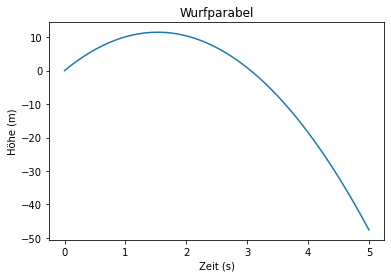

In [7]:
import matplotlib.pyplot as plt
t = np.linspace(0, 5, 100)
y = 15 * t - 9.81 / 2 * t**2

fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
ax.plot(t, y)
ax.set_xlabel('Zeit (s)')
ax.set_ylabel('Höhe (m)')
ax.set_title('Wurfparabel')

## **Aufgabe 2: Histogramm und Rauschen**

a.) Wie bereits in der Vorlesung gezeigt wurde, wollen wir hier das Rauschen in einer Messung genauer anschauen. Laden Sie dazu als erstes den Datensatz `ExampleData.txt`. Der Datensatz beinhaltet eine zeitabhängige Spannung mit den Spalten: $t$, $V$. Plotten Sie die Zeitabhängigkeit der Spannung.


### Lösung

(2, 20000)


Text(0, 0.5, 'V (V)')

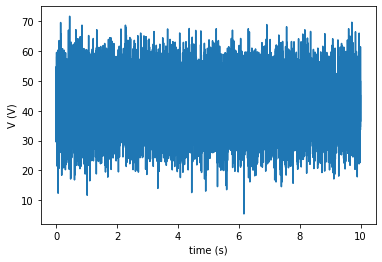

In [8]:
data = np.loadtxt('ExampleData.txt', skiprows=1, delimiter=',')
print(data.shape)

# Wir weisen den 2D Datensatz verschiedenen 1D Arrays zu
t = data[0,:]
V = data[1,:]

fig = plt.figure()
ax = fig.add_subplot(1,1,1)
ax.plot(t,V)
ax.set_xlabel('time (s)')
ax.set_ylabel('V (V)')


b.) Berechnen Sie Mittelwert und Standardabweichung der Spannung.

### Lösung

In [9]:
V_mean = np.mean(V)
V_std = np.std(V)

print('V = {:0.3f} +/- {:0.3f} V'.format(V_mean,V_std))


V = 42.019 +/- 7.992 V


c.) Plotten Sie das Histogramm der Spannung. Um das Histogramm zu berechnen, können Sie `np.histogram()`, und um es in der gewohnten Balken-Form zu plotten `ax.bar()` verwenden. Die Grösse der Bins hat einen grossen Einfluss auf das Histogramm. Testen Sie verschiedene Grössen aus! Was sehen Sie?

Die Syntax der Funktionen finden Sie wieder mit der Hilfe Funktionen: `np.histogram?` und `ax.bar?`.

Beachten Sie, dass die Breite der Balken im Plot kleiner als die Bingrösse gewählt werden sollte.

### Lösung

Text(0, 0.5, 'Occurrences')

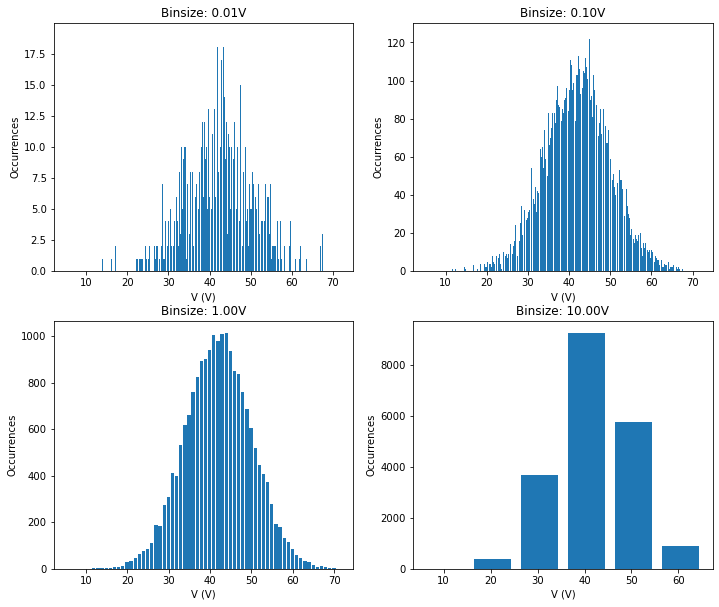

In [10]:
cm = 0.393701  # Umrechnung Zoll zu Centimeter

# Wir wählen eine Binsize und erstellen dann zuerst die Bins für jede Beschleunigungskomponente.
# Wir suchen dazu das Minimum und das Maximum der vorhandenen Werte
# Anschliessend berechnen wir das Histogramm. 
binsize = 0.01
bin_edges = np.arange(np.min(V), np.max(V), binsize)
# Da die Funktion zwei Werte zurückgibt, wir aber nur am ersten interessiert sind, können
# wir folgende Syntax verwenden, um den zweiten Wert gleich zu verwerfen:
hist, _ = np.histogram(V, bin_edges)
# Das Array 'bin_edges' gibt die Grenzen der Bins an, für den Plot brauchen wir aber die Mitte
# der Bins, um die Balken richtig zu positionieren
bin_centers = bin_edges[:-1] + 0.5 * binsize

# Wir plotten die drei bar plots und wählen die 'width' etwas kleiner als die binsize. 
fig = plt.figure(figsize=(30*cm, 25.5*cm))
ax1 = fig.add_subplot(2,2,1)
ax1.bar(bin_centers, hist, width=0.8*binsize)
ax1.set_title('Binsize: {:.2f}V'.format(binsize))
# Wir wiederholen den Vorgang für verschiedene binsizes.
# Natürlich kannst du hier auch eine Funktion definieren, anstatt den selben Code mehrere mal zu schreiben. 
binsize = 0.1
bin_edges = np.arange(np.min(V), np.max(V), binsize)
hist, _ = np.histogram(V, bin_edges)
bin_centers = bin_edges[:-1] + 0.5 * binsize

ax2 = fig.add_subplot(2,2,2)
ax2.bar(bin_centers, hist, width=0.8*binsize)
ax2.set_title('Binsize: {:.2f}V'.format(binsize))

binsize = 1
bin_edges = np.arange(np.min(V), np.max(V), binsize)
hist, _ = np.histogram(V, bin_edges)
bin_centers = bin_edges[:-1] + 0.5 * binsize

ax3 = fig.add_subplot(2,2,3)
ax3.bar(bin_centers, hist, width=0.8*binsize)
ax3.set_title('Binsize: {:.2f}V'.format(binsize))


binsize = 10
bin_edges = np.arange(np.min(V), np.max(V), binsize)
hist, _ = np.histogram(V, bin_edges)
bin_centers = bin_edges[:-1] + 0.5 * binsize

ax4 = fig.add_subplot(2,2,4)
ax4.bar(bin_centers, hist, width=0.8*binsize)
ax4.set_title('Binsize: {:.2f}V'.format(binsize))

ax1.set_xlabel('V (V)')
ax2.set_xlabel('V (V)')
ax3.set_xlabel('V (V)')
ax4.set_xlabel('V (V)')
ax1.set_ylabel('Occurrences')
ax2.set_ylabel('Occurrences')
ax3.set_ylabel('Occurrences')
ax4.set_ylabel('Occurrences')


d.) Zuletzt plotten Sie nochmals das Histogramm mit einer sinnvollen Bin-Grösse, und zeichnen Sie den Mittelwert sowie die Standardabweichung ein. Hierzu können Sie die Funktion `ax.axvline` des Achsenobjekts verwenden.


Text(0.5, 1.0, 'Binsize: 1.00V')

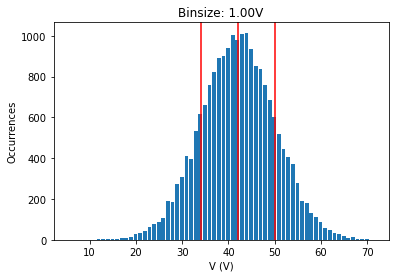

In [11]:
binsize = 1
bin_edges = np.arange(np.min(V), np.max(V), binsize)
hist, _ = np.histogram(V, bin_edges)
bin_centers = bin_edges[:-1] + 0.5 * binsize

fig = plt.figure()
ax = fig.add_subplot(1,1,1)
ax.bar(bin_centers, hist, width=0.8*binsize)
ax.axvline(V_mean, color='r')
ax.axvline(V_mean-V_std, color='r')
ax.axvline(V_mean+V_std, color='r')

ax.set_xlabel('V (V)')
ax.set_ylabel('Occurrences')
ax.set_title('Binsize: {:.2f}V'.format(binsize))

## **Zusatzaufgabe: Zentraler Grenzwertsatz**

Wie in der Vorlesung gezeigt wurde, ergibt eine additive Überlagerung unabhängiger Zufallseffekte im Gesamten zumindest Näherungsweise eine Normalverteilung. In der Vorlesung wurde dies anhand von Würfeln gezeigt, hier versuchen wir das Ergebnis mit (virtuellen) Münzen zu reproduzieren. Hierzu weisen wir Kopf und Zahl einfach zwei Zahlenwerte zu, 0 und 1. 

a) Generieren Sie als erstes die Zufallswerte für den Münzwurf. Dazu eignet sich z.B. `np.random.randint()`. Werfen Sie dafür gleichzeitig N Münzen und schauen Sie sich das Histogramm der Ergebnisse an. Wählen Sie dabei N gross genug, um zu überprüfen ob beide möglichen Werte gleich oft vorkommen.

### Lösung:

Text(0.5, 1.0, 'Tossing 2000 coins')

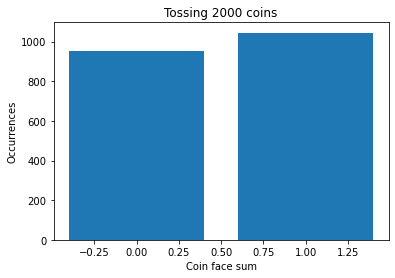

In [12]:
Ncoins = 2000
coin = np.random.randint(0, 2, Ncoins)
bin_edges = np.array([-.5, .5, 1.5])  # die Ränder der Bins, zentriert um die Werte 0 und 1.
hist, _ = np.histogram(coin, bin_edges)
bin_centers = [0, 1]

fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
ax.bar(bin_centers, hist, width=0.8)

ax.set_xlabel('Coin face sum')
ax.set_ylabel('Occurrences')
ax.set_title('Tossing {:d} coins'.format(Ncoins))

b) Wiederholen Sie als nächstes dieses Experiment M-mal, und summieren Sie für jede der N Münzen die M Ergebnisse auf. Plotten Sie dann das Histogramm der Summen und die dazugehörige (skalierte) Normalverteilung

$p(x) = \frac{N}{\sqrt{2\pi\sigma^2}}e{\frac{-(x-\mu)^2}{2\sigma^2}}$.

Vergleichen Sie es für verschiedene Anzahl Wiederholungen.

### Lösung

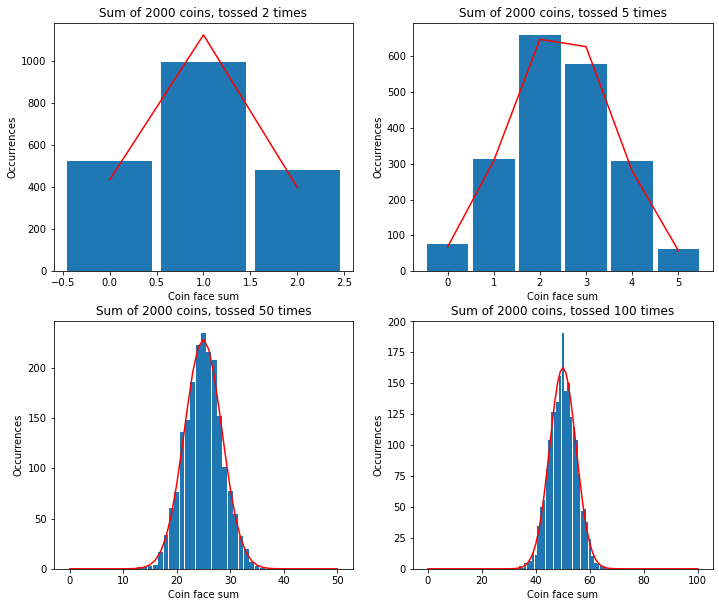

In [ ]:
cm = 0.393701  # Umrechnung Zoll zu Centimeter

Ncoins = 2000
Mtosses = np.array([2, 5, 50, 100])
fig = plt.figure(figsize=(30*cm, 25.5*cm))

for i in range(len(Mtosses)):
    s = np.zeros(Ncoins, dtype=int)
    
    for j in range(Mtosses[i]):
        s = s + np.random.randint(0,2, Ncoins)

    bin_edges = np.arange(0, Mtosses[i]+2) - 0.5
    hist, _ = np.histogram(s, bin_edges)
    bin_centers = np.arange(0, Mtosses[i]+1)
    
    mean = np.mean(s)
    var = np.var(s)
    gauss = Ncoins / np.sqrt(2 * np.pi * var) * np.exp(-(bin_centers - mean)**2 / (2 * var))

    ax = fig.add_subplot(2, 2, i+1)
    ax.bar(bin_centers, hist, width=(bin_centers[1] - bin_centers[0])*0.9)
    ax.plot(bin_centers, gauss, color='r')
    ax.set_xlabel('Coin face sum')
    ax.set_ylabel('Occurrences')
    ax.set_title('Sum of {:d} coins, tossed {:d} times'.format(Ncoins, Mtosses[i]))